# Appendix — Grid-cell geometry, neuron labels, and inverted spatial maps

A self-contained companion to `grid-cell-phenomenology-old.ipynb`, producing three appendix figure workflows. **Run All from a fresh Python kernel.** No `src` package, trained model, data download, Torch, or full RNN allocation is needed; the selected neurons are evaluated directly from the analytical construction.

| Workflow | Main output | Keynote exports |
|---|---|---|
| Figure 11 | **3 rows × 4 columns**: tiling geometry, frequency orbit, actual spatial tuning for $m=2,3,4,6$ | Geometry, clean character grids, individual orbit bands, tuning, and real orbit-sum panels |
| Figure 12 | **4 modules × 7 label choices** | One complete individual-neuron panel (SVG/PDF), with raw spatial maps and diagnostics |
| Figure 13 | **The same 4 modules × 3 columns**: $\epsilon_2=+1$, $\epsilon_2=-1$, and direct sigma-pi tuning | Full comparison, individual maps, and colorbars; sigma-pi uses a distinct, zero-centered colormap |

The figure numbers are editable below. SVG and PDF exports go into `appendix_figures/figure11`, `figure12`, and `figure13`. A visible `appendix_figures/cache` folder avoids recomputation. Each figure also saves raw numerical arrays and diagnostic tables. Full panels and, where requested, individual assets are ready for assembly in Keynote.

**Important distinctions:** individual squared-ReLU tuning is not the same as paired tuning; exact global averaging is not the long-time limit of a local-only walk; display normalization is applied only after the raw computations. Assertions below check the claims instead of assuming the sketched label effects.


In [13]:
# If needed, run once:
# %pip install numpy matplotlib ipython

from dataclasses import dataclass, replace, asdict
from functools import lru_cache
from pathlib import Path
import hashlib
import json
import time
import csv
import marshal
import io
import numpy as np

@dataclass(frozen=True)
class Labels:
    eps1: int = 1
    eps2: int = 1
    delta: int = 0
    k0: int = 0
    k1: int = 0
    k2: int = 0

## Settings

The label-sweep defaults match the source notebook: $n=21$, $q=3$, modules $(9,19,20,21)$, a periodic Gaussian reference of width 1 centered at $(2,2)$, and heading weights $(1,.8,.4,.2,.4,.8)$. Figure 11 uses a centered bump and uniform heading weights to isolate the effect of changing $m$. Module numbers depend on $n$; their frequency orbits are saved with the results.

In [14]:
# Change these settings, then Run All. No repository or external data is needed.
N = 21
Q = 3
OUTPUT_ROOT = Path('appendix_figures')
EXPORT_FORMATS = ('svg', 'pdf')
SHOW_FIGURES = True
SAVE_INDIVIDUAL_PANELS = True
TRANSPARENT_PANELS = True
USE_CACHE = True
BATCH_SIZE = 96  # Target poses per batch; reduce if memory is limited.

FIGURE11 = dict(number=11, m_values=(2,3,4,6), seed=(2,0), atlas_radius=3,
                tuning_kind='single', reference_center=(0,0), uniform_heading=True,
                band_cmap='coolwarm', bank_background_alpha=.60)
FIGURE12 = dict(number=12, rhos=(9,19,20,21))
FIGURE13 = dict(number=13, rhos=FIGURE12['rhos'], sigma_pi_cmap='RdBu_r',
                save_individual_panels=True)

# Figure 12/13 reference settings from the attached notebook/manuscript.
REFERENCE_CENTER = (2,2)
REFERENCE_SIGMA = 1.0
HEADING_WEIGHTS = (1.0,.8,.4,.2,.4,.8)
BASE_LABELS = Labels(eps1=1,eps2=1,delta=0,k0=0,k1=0,k2=0)

# Seven columns: reference followed by a change to exactly one label.
LABEL_CHANGES = (
    ('reference','Reference',{}),
    ('eps1',r'flip $\epsilon_1$',{'eps1':-1}),
    ('eps2',r'flip $\epsilon_2$',{'eps2':-1}),
    ('delta',r'$\delta:0\to1$',{'delta':1}),
    ('k0',r'$k_0:0\to1$',{'k0':1}),
    ('k1',r'$k_1:0\to1$',{'k1':1}),
    ('k2',r'$k_2:0\to1$',{'k2':1}),
)
if not EXPORT_FORMATS or any(f not in ('svg','pdf','png') for f in EXPORT_FORMATS):
    raise ValueError('Use svg, pdf, and/or png export formats.')
OUTPUT_ROOT.mkdir(parents=True,exist_ok=True)
CACHE_DIR = OUTPUT_ROOT/'cache' if USE_CACHE else None
F11 = OUTPUT_ROOT/f'figure{FIGURE11["number"]}'
F12 = OUTPUT_ROOT/f'figure{FIGURE12["number"]}'
F13 = OUTPUT_ROOT/f'figure{FIGURE13["number"]}'
print('Output folder:', OUTPUT_ROOT.resolve())
print('Tuning convention: exact global one-step averaging; right-regular circuit.')


Output folder: /Users/danielkunin/Desktop/Grid Cells and Group Composition/code/grids-and-groups/notebooks/constructed_networks/appendix_figures
Tuning convention: exact global one-step averaging; right-regular circuit.


## Scalar construction and conventions

For a selected irrep of dimension $d$, write $\phi=\pi\delta/q$ and
\[
U_i(a)=A_u\operatorname{Re}\!\left[e^{-i\phi}(B Q(a))_{k_0k_2}\right],\qquad
V_{0,i}(b)=A_v\operatorname{Re}\!\left[e^{-i\phi}Q(b)_{k_2k_1}\right].
\]
The hidden response is $\operatorname{ReLU}[\epsilon_1(U_i(a)+\epsilon_2V_{0,i}(b))]^2$.
For a target $g=ab$, global tuning is the **exact finite average over every $a\in G$**, using $b=a^{-1}g$. The spatial marginal averages equally over all headings. There is no Monte Carlo approximation.

**Right-regular bookkeeping.** The source notebook specifies `action_side="right"`. If $D(g)$ are the standard induced representation matrices, the opposite-group weight matrices are $T(g)=D(g)^\top$. The scalar inputs use $Q(g)=T(g)^\dagger=\overline{D(g)}$, which is a representation of the physical product, and $B=\sum_g x^{\rm ref}(g)T(g)^\dagger$. This distinction prevents a silent transpose or phase change when replacing the full model by scalar inputs. The direct-weight check below verifies $u^\top x_{\rm allo}(a)=U_i(a)$ independently. In the manuscript's $M_i$ expression, use the irrep appearing in the scalar input—called $Q$ here—and its corresponding fixed coefficient $B$ in $U_i$.

The periodic Gaussian uses minimum Euclidean distance on the square/triangular torus. We make the balanced amplitude choice explicit: $A_u=A_v=A_w=(d/(q|G|))^{1/3}$. Only selected irreps and neurons are instantiated; a hidden-width budget cannot change the selected maps. The random egocentric reference cancels from $V_0$ after its invertible Fourier block is applied, so it need not be sampled or stored.

In [15]:
ROTATIONS = {
    2: np.array([[-1, 0], [0, -1]], dtype=int),
    3: np.array([[-1, -1], [1, 0]], dtype=int),
    4: np.array([[0, -1], [1, 0]], dtype=int),
    6: np.array([[0, -1], [1, 1]], dtype=int),
}

def centered_frequency(k, n):
    return tuple((int(v) + n // 2) % n - n // 2 for v in k)

def rotation_powers(m):
    A = ROTATIONS[m]
    return np.array([np.linalg.matrix_power(A, r) for r in range(m)])

def character_orbit(n, m, seed):
    # Covectors transform by A^{-T}, not A.
    dual = np.rint(np.linalg.inv(ROTATIONS[m]).T).astype(int)
    point, orbit = np.asarray(seed, dtype=int) % n, []
    while tuple(point) not in orbit:
        orbit.append(tuple(int(v) for v in point))
        point = (dual @ point) % n
    return tuple(orbit)

@lru_cache(None)
def irrep_catalog(n, m):
    # Same ordering as DiscreteSE2Group: increasing orbit size, then first
    # lexicographic representative, then stabilizer character.
    seen, families = set(), {}
    for x in range(n):
        for y in range(n):
            if (x, y) not in seen:
                orbit = character_orbit(n, m, (x, y))
                seen.update(orbit)
                families.setdefault(len(orbit), []).append(orbit)
    catalog = []
    for d in sorted(families):
        for orbit in families[d]:
            for s in range(m // d):
                catalog.append((orbit, s))
    assert sum(len(o)**2 for o, _ in catalog) == m * n**2
    return tuple(catalog)

class SelectedCircuit:
    """One irrep and its exact scalar inputs, with no full RNN allocation.

    Group indexing is r*n*n + x*n + y; pose arrays have shape (m,n,n).
    The right-regular implementation uses T(g)=rho_base(g)^T in its weights.
    Its scalar inputs use Q(g)=T(g)^dagger=conj(rho_base(g)), a representation
    of the physical product. Here self.rho denotes Q and self.X denotes
    sum_g x_ref(g) T(g)^dagger. See the notebook's convention note.
    """
    def __init__(self, n, m, *, rho_index=None, seed=None, q=3, center=(2, 2),
                 sigma=1.0, heading_weights=None, amplitude_u=None, amplitude_v=None,
                 action_side='right'):
        if (rho_index is None) == (seed is None):
            raise ValueError('Choose exactly one of rho_index and seed.')
        if n < 3 or m not in ROTATIONS or q < 3 or sigma <= 0:
            raise ValueError('Require n>=3, m in (2,3,4,6), q>=3, sigma>0.')
        self.n, self.m, self.q = int(n), int(m), int(q)
        if action_side not in ('right', 'left'):
            raise ValueError('action_side must be right or left')
        self.action_side = action_side
        self.order = m*n*n
        self.rot = rotation_powers(m)
        catalog = irrep_catalog(n, m)
        if seed is not None:
            target = set(character_orbit(n, m, seed))
            rho_index = next(i for i, (o, s) in enumerate(catalog)
                             if set(o) == target and s == 0)
        if not 0 <= rho_index < len(catalog):
            raise ValueError(f'rho_index={rho_index} outside 0..{len(catalog)-1}')
        self.rho_index = int(rho_index)
        self.orbit, self.stabilizer_index = catalog[rho_index]
        if seed is not None:
            # Keep the same initial basis vector when comparing different m.
            self.orbit = character_orbit(n, m, seed)
        self.d = len(self.orbit)
        self.r, self.x, self.y = np.indices((m, n, n)).reshape(3, -1)
        self.coords = np.column_stack((self.x, self.y))
        self.rho = np.zeros((self.order, self.d, self.d), dtype=complex)
        orbit = np.array(self.orbit)
        for j in range(self.d):
            i = (self.r + j) % self.d
            wrap = (self.r + j) // self.d
            phase = (orbit[i, 0]*self.x + orbit[i, 1]*self.y)/n
            phase += self.stabilizer_index*wrap/(m/self.d)
            self.rho[np.arange(self.order), i, j] = np.exp(2j*np.pi*phase)
        self.weight_rho = (self.rho.transpose(0, 2, 1).copy()
                           if action_side == 'right' else self.rho.copy())
        self.rho = self.weight_rho.conj().transpose(0, 2, 1).copy()
        if heading_weights is None:
            # Periodic linear interpolation of the six-heading reference.
            heading_weights = np.interp(np.arange(m)/m, np.arange(7)/6,
                                       [1, .8, .4, .2, .4, .8, 1])
        heading_weights = np.asarray(heading_weights, float)
        if heading_weights.shape != (m,) or np.any(heading_weights < 0):
            raise ValueError('heading_weights must contain m nonnegative entries.')
        basis = (np.array([[1., .5], [0., np.sqrt(3)/2]])
                 if m in (3, 6) else np.eye(2))
        xy = np.indices((n, n)).reshape(2, -1).T
        displacement = xy - np.asarray(center) % n
        distance2 = np.full(n*n, np.inf)
        for i in (-1, 0, 1):
            for j in (-1, 0, 1):
                euclidean = (displacement + n*np.array([i, j])) @ basis.T
                distance2 = np.minimum(distance2, np.sum(euclidean**2, axis=1))
        bump = np.exp(-distance2/(2*sigma**2))
        self.reference = (heading_weights[:, None]*bump).ravel()
        self.X = np.einsum('g,gij->ij', self.reference, self.rho)
        amplitude = (self.d/(q*self.order))**(1/3)
        self.Au = amplitude if amplitude_u is None else float(amplitude_u)
        self.Av = amplitude if amplitude_v is None else float(amplitude_v)
        self.Aw = self.d/(q*self.order*self.Au*self.Av)
        self.settings = dict(n=n, m=m, rho_index=self.rho_index, q=q,
                             center=list(center), sigma=sigma,
                             heading_weights=heading_weights.tolist(),
                             Au=self.Au, Av=self.Av, Aw=self.Aw, action_side=action_side,
                             basis_seed=None if seed is None else list(seed))

    def encode(self, x, y, r):
        return (np.asarray(r) % self.m)*self.n**2 + (np.asarray(x) % self.n)*self.n + np.asarray(y) % self.n

    def compose(self, a, b):
        if self.action_side == 'left':
            a, b = b, a
        a, b = np.asarray(a), np.asarray(b)
        rotated = np.einsum('...ij,...j->...i', self.rot[self.r[a]], self.coords[b])
        xy = self.coords[a] + rotated
        return self.encode(xy[..., 0], xy[..., 1], self.r[a] + self.r[b])

    def inverse(self, a):
        a = np.asarray(a)
        xy = -np.einsum('...ij,...j->...i', self.rot[-self.r[a] % self.m], self.coords[a])
        return self.encode(xy[..., 0], xy[..., 1], -self.r[a])

    def inputs(self, labels):
        if labels.eps1 not in (-1, 1) or labels.eps2 not in (-1, 1):
            raise ValueError('Signs must be +/-1.')
        if not 0 <= labels.delta < self.q or not all(0 <= k < self.d for k in (labels.k0, labels.k1, labels.k2)):
            raise ValueError('Phase or matrix index outside this irrep.')
        phase = np.exp(-1j*np.pi*labels.delta/self.q)
        # epsilon_1 is applied after summing U and epsilon_2*V0.
        U = self.Au*(phase*np.einsum('j,gj->g', self.X[labels.k0], self.rho[:, :, labels.k2])).real
        V0 = self.Av*(phase*self.rho[:, labels.k2, labels.k1]).real
        return U, V0

    def theory(self, labels):
        U, V0 = self.inputs(labels)
        C = np.mean(U**2 + V0**2)
        E = np.zeros((self.d, self.d), complex)
        E[labels.k1, labels.k2] = 1
        weighted_inverse = np.einsum('g,gji->ij', U, self.rho.conj())
        M = (2*labels.eps2*self.Av*np.exp(-1j*np.pi*labels.delta/self.q)/self.order)*E@weighted_inverse
        cross = np.einsum('gij,ji->g', self.rho, M).real
        return dict(C=C, M=M, paired=(C+cross).reshape(self.m, self.n, self.n),
                    cross=cross.reshape(self.m, self.n, self.n))

    def sigma_pi_tuning(self, labels, *, batch_size=96):
        """Direct global mean of U(a)*V0(a^{-1}g), with no rectification.

        This is the canonical signed product; epsilon_1/epsilon_2 channel
        labels are unnecessary when the multiplication itself is available.
        """
        U,V0=self.inputs(labels)
        values=np.empty(self.order)
        inverse_a=self.inverse(np.arange(self.order))
        for start in range(0,self.order,batch_size):
            g=np.arange(start,min(start+batch_size,self.order))
            b=self.compose(inverse_a[None,:],g[:,None])
            values[g]=np.mean(U[None,:]*V0[b],axis=1)
        return values.reshape(self.m,self.n,self.n)

    def tune(self, labels, *, batch_size=96, cache_dir=None):
        """Exact global one-step mean for BOTH epsilon_1 signs; float64.

        Paired curves are computed independently as the mean of z^2, so the
        separate matrix formula can be checked without circular validation.
        """
        U, V0 = self.inputs(labels)
        # The cache also hashes implementation bytecode, including constants.
        h = hashlib.sha256()
        for fn in (type(self).__init__, type(self).inputs, type(self).tune,
                   type(self).compose, type(self).inverse):
            h.update(marshal.dumps(fn.__code__))
        h.update(json.dumps(dict(settings=self.settings, labels=asdict(replace(labels, eps1=1))), sort_keys=True).encode())
        for values in (U, V0, self.rot):
            h.update(np.ascontiguousarray(values).tobytes())
        key = h.hexdigest()[:24]
        path = None if cache_dir is None else Path(cache_dir)/f'global_{key}.npz'
        if path is not None and path.exists():
            with np.load(path, allow_pickle=False) as f:
                return {k: f[k].copy() for k in f.files}
        positive, negative, square = (np.empty(self.order) for _ in range(3))
        inverse_a = self.inverse(np.arange(self.order))
        for start in range(0, self.order, batch_size):
            g = np.arange(start, min(start+batch_size, self.order))
            b = self.compose(inverse_a[None, :], g[:, None])
            z = U[None, :] + labels.eps2*V0[b]
            positive[g] = np.mean(np.maximum(z, 0)**2, axis=1)
            negative[g] = np.mean(np.maximum(-z, 0)**2, axis=1)
            square[g] = np.mean(z*z, axis=1)
        shape = (self.m, self.n, self.n)
        result = dict(plus=positive.reshape(shape), minus=negative.reshape(shape),
                      paired=square.reshape(shape))
        if path is not None:
            path.parent.mkdir(parents=True, exist_ok=True)
            buffer = io.BytesIO()
            np.savez_compressed(buffer, **result)
            path.write_bytes(buffer.getvalue())
        return result

def select_curve(result, labels, kind='single'):
    if kind == 'paired':
        return result['paired']
    if kind == 'single':
        return result['plus' if labels.eps1 == 1 else 'minus']
    raise ValueError('kind must be single or paired')

def spatial_map(curve):
    return np.asarray(curve).mean(axis=0)

def center_map(values):
    values = np.asarray(values, float)
    return values-values.mean()

def map_correlation(a, b):
    a, b = center_map(a).ravel(), center_map(b).ravel()
    denom = np.linalg.norm(a)*np.linalg.norm(b)
    return float(a@b/denom) if denom > 1e-24 else np.nan

def normalized_map(values):
    values = np.asarray(values, float)
    span = np.ptp(values)
    if span < 1e-12*max(1., np.max(np.abs(values))):
        return np.full_like(values, .5)
    return (values-values.min())/span

def periodic_autocorrelation(values):
    centered = center_map(values)
    if np.linalg.norm(centered) < 1e-12*max(1., np.linalg.norm(values)):
        return np.full_like(centered, np.nan)
    ac = np.fft.ifft2(np.abs(np.fft.fft2(centered))**2).real
    return np.fft.fftshift(ac/ac[0, 0])


## Plotting and export helpers

Spatial arrays use `(x, y)` axes; full tuning arrays use `(heading, x, y)`. Hexagonal panels use a periodic rectangular cut of the axial lattice. The cells, band fills, and subtle orbit outlines are vector graphics in the SVG/PDF exports. Character grids and individual bands have no axes or arrows; geometry panels retain their forward-direction arrows. Figure 11 saves separate clean components for Keynote; Figure 12 saves only its complete individual-neuron panel.

In [28]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle, RegularPolygon, FancyArrowPatch
from IPython.display import display, Markdown

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'svg.fonttype': 'none', 'pdf.fonttype': 42,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120, 'savefig.dpi': 220,
})
exported_paths = []

def export_figure(fig, folder, stem, *, show=False):
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)
    for extension in EXPORT_FORMATS:
        path = folder/f'{stem}.{extension}'
        buffer=io.BytesIO()
        fig.savefig(buffer, format=extension, bbox_inches='tight', pad_inches=.045,
                    transparent=TRANSPARENT_PANELS)
        path.write_bytes(buffer.getvalue())
        exported_paths.append(path)
    if show and SHOW_FIGURES:
        display(fig)
    plt.close(fig)

def write_csv(path, rows):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if rows:
        with path.open('w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0]))
            writer.writeheader()
            writer.writerows(rows)
    exported_paths.append(path)

def save_arrays(folder, stem, **arrays):
    folder = Path(folder)/'data'
    folder.mkdir(parents=True, exist_ok=True)
    path = folder/f'{stem}.npz'
    buffer=io.BytesIO()
    np.savez_compressed(buffer, **arrays)
    path.write_bytes(buffer.getvalue())
    exported_paths.append(path)

def plot_lattice(values, ax, m=6, *, cmap='viridis', vmin=None, vmax=None):
    """Vector square/hex cells. Input axes are (x,y), never (row,column).

    Hex display is a rectangular cut of the axial torus; values, including
    the clipped left/right edge cells, are indexed periodically.
    """
    values = np.asarray(values)
    n = values.shape[0]
    if values.shape != (n, n):
        raise ValueError('Expected an n by n scalar map.')
    if m in (3, 6):
        rows, cols = np.meshgrid(np.arange(n), np.arange(-1, n+1), indexing='ij')
        yy, cc = rows.ravel(), cols.ravel()
        xx = (cc-yy//2) % n
        centers = np.column_stack((cc+.5*(yy % 2), np.sqrt(3)/2*yy))
        angles = np.pi/6 + np.arange(6)*np.pi/3
        offsets = np.column_stack((np.cos(angles), np.sin(angles)))/np.sqrt(3)
        colors = values[xx, yy]
        ylim = (-1/np.sqrt(3), np.sqrt(3)/2*(n-1)+1/np.sqrt(3))
    else:
        xx, yy = np.indices((n, n))
        centers = np.column_stack((xx.ravel(), yy.ravel()))
        offsets = np.array([[-.5,-.5],[.5,-.5],[.5,.5],[-.5,.5]])
        colors = values.ravel()
        ylim = (-.5, n-.5)
    collection = PolyCollection(centers[:, None, :]+offsets, array=colors,
                                cmap=cmap, norm=Normalize(vmin, vmax),
                                edgecolors='face', linewidths=.10, antialiased=False)
    ax.add_collection(collection)
    ax.set(xlim=(-.5, n-.5), ylim=ylim, aspect='equal')
    ax.set_axis_off()
    return collection

def scalar_panel(values, folder, stem, *, m=6, cmap='viridis', vmin=0, vmax=1):
    fig, ax = plt.subplots(figsize=(3, 3))
    plot_lattice(values, ax, m, cmap=cmap, vmin=vmin, vmax=vmax)
    fig.subplots_adjust(0, 0, 1, 1)
    export_figure(fig, folder, stem)

def plot_geometry(ax, m, annotate=True):
    basis = np.array([[1., .5], [0., np.sqrt(3)/2]]) if m in (3,6) else np.eye(2)
    coords = np.array([
        (i - int(j / 2), j) if m in (3, 6) else (i, j)
        for j in range(-2, 3)
        for i in range(-2, 3)
    ])
    centers = coords @ basis.T
    for xy in centers:
        patch = (RegularPolygon(xy, 6, radius=1/np.sqrt(3), orientation=0,
                                facecolor='white', edgecolor='.77', linewidth=.9)
                 if m in (3,6) else Rectangle(xy-.5,1,1,facecolor='white',
                                               edgecolor='.77',linewidth=.9))
        ax.add_patch(patch)
    ax.scatter(*centers.T, s=7, c='.25', zorder=3)
    neighbor_steps = [(1,0),(-1,0),(0,1),(0,-1)]
    if m in (3,6):
        neighbor_steps += [(1,-1),(-1,1)]
    for t in neighbor_steps:
        p = basis@t
        ax.plot([0,p[0]],[0,p[1]],color='.42',lw=1.3,zorder=3)
    for R in rotation_powers(m):
        p = basis@(R@np.array([1,0]))
        ax.add_patch(FancyArrowPatch((0,0),.94*p,arrowstyle='-|>',
                                    mutation_scale=14,color='#de2d47',lw=2,zorder=4))
    ax.scatter([0],[0],s=23,c='.18',zorder=5)
    cell_half_size = np.array([
        0.5,
        1 / np.sqrt(3) if m in (3, 6) else 0.5,
    ])
    extent = np.max(np.abs(centers), axis=0) + cell_half_size + 0.12
    ax.set(
        xlim=(-extent[0], extent[0]),
        ylim=(-extent[1], extent[1]),
        aspect="equal",
    )
    ax.set_axis_off()
    if annotate:
        tiling = 'hexagonal' if m in (3,6) else 'square'
        ax.text(.5, 1.01, f'{tiling} tiling',transform=ax.transAxes,ha='center',fontsize=11)
        ax.text(.5,-.01, f'{m} allowed forward directions',transform=ax.transAxes,ha='center',fontsize=9)

def draw_character_band(ax, k, extent=(-.5,.5,-.5,.5), *, cmap='coolwarm', alpha=1.):
    """Real translation character, drawn as vector fills with no decorations."""
    uv=np.linspace(0,1,37)
    u,v=np.meshgrid(uv,uv,indexing='xy')
    wave=np.cos(2*np.pi*(k[0]*u+k[1]*v))
    left,right,bottom,top=extent
    return ax.contourf(left+uv*(right-left),bottom+uv*(top-bottom),wave,
                       levels=np.linspace(-1.000001,1.000001,9),
                       cmap=cmap,vmin=-1,vmax=1,alpha=alpha,antialiased=False)

def plot_character_bank(ax, n, m, seed=(2,0), radius=3, *, cmap='coolwarm', background_alpha=.60):
    """Character grid only: subtle orbit emphasis, no axes or arrows."""
    orbit = [centered_frequency(k,n) for k in character_orbit(n,m,seed)]
    radius = max(radius, max(abs(v) for k in orbit for v in k))
    width = .90
    for ky in range(-radius,radius+1):
        for kx in range(-radius,radius+1):
            draw_character_band(ax,(kx,ky),
                (kx-width/2,kx+width/2,ky-width/2,ky+width/2),cmap=cmap,
                alpha=1. if (kx,ky) in orbit else background_alpha)
    for k in orbit:
        ax.add_patch(Rectangle(np.array(k)-width/2,width,width,fill=False,
                               edgecolor='.35',alpha=.45,lw=.8,zorder=5))
    ax.set(xlim=(-radius-.48,radius+.48),ylim=(-radius-.48,radius+.48),aspect='equal')
    ax.set_axis_off()

def save_orbit_bands(n, m, seed, folder, *, cmap='coolwarm'):
    """Save every orbit entry; conjugate labels get separate files."""
    for step,k in enumerate(character_orbit(n,m,seed)):
        kx,ky=centered_frequency(k,n)
        fig,ax=plt.subplots(figsize=(3,3))
        draw_character_band(ax,(kx,ky),cmap=cmap)
        ax.set(xlim=(-.5,.5),ylim=(-.5,.5),aspect='equal')
        ax.set_axis_off()
        fig.subplots_adjust(0,0,1,1)
        export_figure(fig,folder,f'step{step:02d}_kx{kx:+d}_ky{ky:+d}')

def gallery(maps, rhos, folder, stem, *, title, labels=(), cmap='viridis', save_individual=False):
    nrows,ncols = len(rhos),len(labels)
    fig,axes = plt.subplots(nrows,ncols,figsize=(1.62*ncols+.5,1.64*nrows+.5),squeeze=False)
    fig.subplots_adjust(left=.07,right=.99,bottom=.02,top=.90,wspace=.09,hspace=.14)
    for row,rho in enumerate(rhos):
        for col,(slug,label,change) in enumerate(labels):
            values=maps[rho][slug]
            plot_lattice(normalized_map(values),axes[row,col],cmap=cmap,vmin=0,vmax=1)
            if row==0:
                axes[row,col].set_title(label,fontsize=10,pad=10)
            if col==0:
                axes[row,col].text(-.09,.5,rf'$\rho={rho}$',transform=axes[row,col].transAxes,
                                   ha='right',va='center',fontsize=11)
            if save_individual:
                scalar_panel(normalized_map(values),folder,f'rho{rho:02d}_{slug}')
    fig.suptitle(title,fontsize=12,y=.99)
    export_figure(fig,folder,stem,show=True)

def colorbar_panel(folder, stem, cmap, low, high, label):
    fig,ax=plt.subplots(figsize=(3.3,.5))
    fig.subplots_adjust(bottom=.55,top=.9)
    cb=fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(low,high),cmap=cmap),
                   cax=ax,orientation='horizontal')
    cb.set_label(label,fontsize=9)
    export_figure(fig,folder,stem)

## Numerical checks

These small-group checks compare representation products, direct scalar weights against Fourier inputs, the independently averaged paired response against $M$, and the signed polarization identity. Later cells also check the Fourier support of the paired spatial maps at the figure resolution.

In [17]:
# Independent algebra and scalar-weight checks on a small group.
check_rows=[]
rng=np.random.default_rng(7)
for m in (2,3,4,6):
    c=SelectedCircuit(7,m,seed=(1,0),q=Q)
    a,b=rng.integers(c.order,size=(2,32))
    rep_error=np.max(np.abs(c.rho[c.compose(a,b)]-c.rho[a]@c.rho[b]))
    assert rep_error<2e-12
    ell=Labels(delta=1,k0=1 % c.d,k1=1 % c.d,k2=(c.d-1))
    U,V=c.inputs(ell)
    u=c.Au*(np.exp(1j*np.pi*ell.delta/Q)*c.weight_rho[:,ell.k2,ell.k0]).real
    elements=np.arange(c.order)
    # Build x_allo(a)[t]=x_ref(t*a^{-1}) directly, independently of Fourier U.
    direct=np.array([u@c.reference[c.compose(elements,c.inverse(g))] for g in a])
    input_error=float(np.max(np.abs(direct-U[a])))
    assert input_error<2e-12
    result=c.tune(ell,batch_size=32)
    th=c.theory(ell)
    matrix_error=float(np.max(np.abs(result['paired']-th['paired'])))
    assert matrix_error<2e-12
    assert np.allclose(result['plus']+result['minus'],result['paired'],atol=1e-12)
    # Polarization is an identity before taking any tuning average.
    u0,v0=U[a],V[b]
    weighted=sum(e2*np.maximum(e1*(u0+e2*v0),0)**2
                 for e1 in (-1,1) for e2 in (-1,1))
    assert np.allclose(weighted,4*u0*v0,atol=1e-12)
    check_rows.append(dict(m=m,representation_error=float(rep_error),
                           direct_input_error=input_error,M_formula_error=matrix_error))
write_csv(OUTPUT_ROOT/'validation'/'algebra_checks.csv',check_rows)
print('Passed: group representations, direct scalar inputs, paired M formula, polarization.')

Passed: group representations, direct scalar inputs, paired M formula, polarization.


## Figure 11 — Tiling geometry, rotation orbits, and tuning

Use the **same seed covector** in each column. Its orbit is computed with the dual action $k\mapsto A_m^{-\top}k$, not by rotating the coordinate pair as though it were a position. For the default seed $(2,0)$, the ordered orbits are

| $m$ | Orbit in centered integer coordinates |
|---|---|
| 2 | $(2,0),(-2,0)$ |
| 3 | $(2,0),(0,2),(-2,-2)$ |
| 4 | $(2,0),(0,2),(-2,0),(0,-2)$ |
| 6 | $(2,0),(2,2),(0,2),(-2,0),(-2,-2),(0,-2)$ |

The square tiling is used for $m=2,4$ and the hexagonal tiling for $m=3,6$. **The tiling alone does not specify the group:** changing $m$ changes the allowed headings and the character orbits. In particular, $m=2$ is also compatible with a triangular translation lattice; the square realization shown here is a choice. Rotating a single forward step with $m=2$ reaches only one translation axis, although the full semidirect-product group still contains all translations.

The bottom row is an actual selected-neuron spatial marginal, not an orbit sum relabeled as activity. To isolate $m$, Figure 11 uses a zero-centered Gaussian and uniform heading amplitudes; the label sweep below restores the original nonuniform heading amplitudes. Real orbit sums are also exported separately: the $m=2$ sum is a band, while the normalized $m=3$ and $m=6$ sums agree because adding the conjugate frequencies doubles the real sum. Individual rectified maps can retain small higher-harmonic differences.

**Export details.** Each `panelb_orbits/m*_character_bank` file contains only the band grid, with subtle emphasis on the orbit and no axes or arrows. `panelb_orbits/m*_bands/` contains one undecorated file per orbit entry, including separate filenames for conjugate frequencies (whose real cosine bands coincide). Bands, real orbit sums, and the bottom tuning row all use `FIGURE11['band_cmap']`, defaulting to `coolwarm`. The real orbit sums use symmetric color limits: white is zero, just as in each band; the nonnegative activity maps retain their stated display normalization.


In [29]:
figure11_data={}
orbit_rows=[]
x,y=np.indices((N,N))
for m in FIGURE11['m_values']:
    circuit=SelectedCircuit(N,m,seed=FIGURE11['seed'],q=Q,
                            center=FIGURE11['reference_center'],sigma=REFERENCE_SIGMA,
                            heading_weights=np.ones(m) if FIGURE11['uniform_heading'] else None)
    orbit=character_orbit(N,m,FIGURE11['seed'])
    real_sum=sum(np.cos(2*np.pi*(kx*x+ky*y)/N) for kx,ky in orbit)
    tuning=circuit.tune(BASE_LABELS,batch_size=BATCH_SIZE,cache_dir=CACHE_DIR)
    pose=select_curve(tuning,BASE_LABELS,FIGURE11['tuning_kind'])
    figure11_data[m]=dict(circuit=circuit,orbit=orbit,orbit_sum=real_sum,
                          pose=pose,spatial=spatial_map(pose))
    save_arrays(F11/'panelc_tuning',f'm{m}',pose_raw=pose,spatial_raw=spatial_map(pose),
                orbit=np.array(orbit),orbit_sum=real_sum,
                settings_json=np.array(json.dumps(circuit.settings)))
    for step,k in enumerate(orbit):
        kx,ky=centered_frequency(k,N)
        orbit_rows.append(dict(m=m,step=step,kx=kx,ky=ky))
write_csv(F11/'panelb_orbits'/'orbits.csv',orbit_rows)
if 2 in figure11_data and FIGURE11['seed'][1]==0:
    assert np.max(np.ptp(figure11_data[2]['spatial'],axis=1))<1e-12
if 3 in figure11_data and 6 in figure11_data:
    sum3,sum6=(figure11_data[m]['orbit_sum'] for m in (3,6))
    assert np.allclose(normalized_map(sum3),normalized_map(sum6),atol=1e-12)
    print('Real orbit sums, m=3 versus m=6: identical after display normalization.')
    print('Actual neuron-map correlation:',
          f"{map_correlation(figure11_data[3]['spatial'],figure11_data[6]['spatial']):.9f}")
print('Frequency orbits (in generator order):')
for m,entry in figure11_data.items():
    print(f'  m={m}:',tuple(centered_frequency(k,N) for k in entry['orbit']))

Real orbit sums, m=3 versus m=6: identical after display normalization.
Actual neuron-map correlation: 1.000000000
Frequency orbits (in generator order):
  m=2: ((2, 0), (-2, 0))
  m=3: ((2, 0), (0, 2), (-2, -2))
  m=4: ((2, 0), (0, 2), (-2, 0), (0, -2))
  m=6: ((2, 0), (2, 2), (0, 2), (-2, 0), (-2, -2), (0, -2))


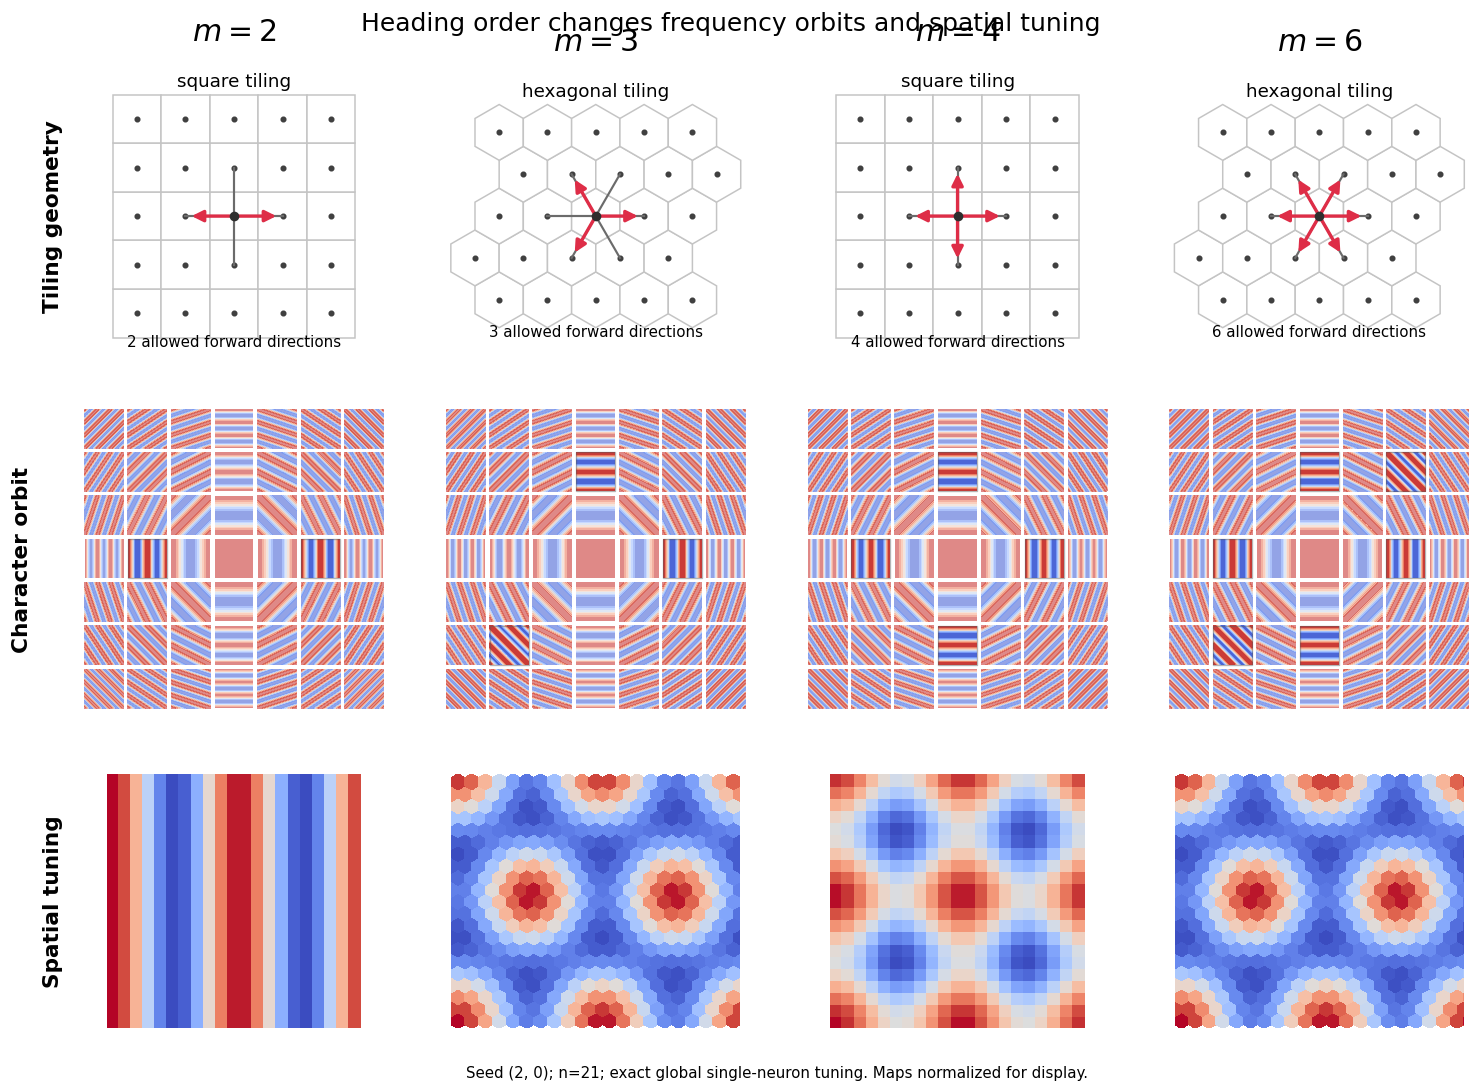

In [30]:
ms=FIGURE11['m_values']
band_cmap=FIGURE11['band_cmap']
bank_style=dict(cmap=band_cmap,background_alpha=FIGURE11['bank_background_alpha'])
fig,axes=plt.subplots(3,len(ms),figsize=(3.0*len(ms)+.7,9.0),squeeze=False,
                      gridspec_kw={'height_ratios':(1.,1.20,1.)})
fig.subplots_adjust(left=.075,right=.985,bottom=.055,top=.925,wspace=.20,hspace=.23)
for col,m in enumerate(ms):
    plot_geometry(axes[0,col],m)
    axes[0,col].set_title(rf'$m={m}$',fontsize=18,pad=29)
    plot_character_bank(axes[1,col],N,m,FIGURE11['seed'],FIGURE11['atlas_radius'],**bank_style)
    plot_lattice(normalized_map(figure11_data[m]['spatial']),axes[2,col],m,cmap=band_cmap,vmin=0,vmax=1)
    if SAVE_INDIVIDUAL_PANELS:
        for kind,plotter,folder in (
            ('geometry',lambda ax,m=m:plot_geometry(ax,m,annotate=False),'panela_geometry'),
            ('character_bank',lambda ax,m=m:plot_character_bank(ax,N,m,FIGURE11['seed'],FIGURE11['atlas_radius'],**bank_style),'panelb_orbits')):
            f,a=plt.subplots(figsize=(3.2,3.2))
            plotter(a)
            export_figure(f,F11/folder,f'm{m}_{kind}')
        scalar_panel(normalized_map(figure11_data[m]['spatial']),F11/'panelc_tuning',f'm{m}_spatial',m=m,cmap=band_cmap)
        # Symmetric limits preserve the same zero-centered color meaning as
        # each band. This is equivalent to plotting the orbit average on [-1,1].
        orbit_size=len(figure11_data[m]['orbit'])
        scalar_panel(figure11_data[m]['orbit_sum'],F11/'panelb_orbits',f'm{m}_real_orbit_sum',
                     m=m,cmap=band_cmap,vmin=-orbit_size,vmax=orbit_size)
        save_orbit_bands(N,m,FIGURE11['seed'],F11/'panelb_orbits'/f'm{m}_bands',cmap=band_cmap)
for row,text in enumerate(('Tiling geometry','Character orbit','Spatial tuning')):
    axes[row,0].text(-.17,.5,text,transform=axes[row,0].transAxes,rotation=90,
                     ha='right',va='center',fontsize=13,fontweight='bold')
fig.suptitle('Heading order changes frequency orbits and spatial tuning',fontsize=15,y=.997)
fig.text(.53,.01,f"Seed {FIGURE11['seed']}; n={N}; exact global {FIGURE11['tuning_kind']}-neuron tuning. Maps normalized for display.",
         ha='center',fontsize=9)
export_figure(fig,F11,'figure11_overview',show=True)
colorbar_panel(F11/'panelc_tuning','display_colorbar',band_cmap,0,1,'Display-normalized activity')
colorbar_panel(F11/'panelb_orbits','band_colorbar',band_cmap,-1,1,'Real character / orbit average')

**Caption draft.** Heading order changes frequency orbits and spatial tuning. Columns show $m=2,3,4,6$. Top: compatible tilings; dots mark position states, gray segments join neighboring cells, and red arrows show the orbit of a forward translation under the heading subgroup. Middle: the $C_m$ orbit of a shared seed character of $C_n^2$, computed using $A_m^{-\top}$; orbit members are lightly emphasized within an undecorated character grid. Bottom: exact global spatial tuning of a selected squared-ReLU neuron, with a uniform heading reference and all labels held fixed. Although $m=2$ and $m=4$ share a square realization, their orbits produce band-like and square-periodic maps, respectively. The $m=3$ and $m=6$ realizations share hexagonal geometry; their real orbit sums have the same normalized shape. Each activity map is normalized only for display. The separate triangular-face schematic is omitted. Bands and their superpositions use the same blue-white-red colormap.

## Figure 12 — Changing one neuron label inside a module

Each row is one irrep. Columns are the reference and changes to $\epsilon_1,\epsilon_2,\delta,k_0,k_1,k_2$, one at a time. Only the **complete individual-neuron panel** is exported, in SVG and PDF under `figure12/full_panel/`. Paired curves and $M$ remain internal numerical checks and supply the Figure 13 analysis.

For fixed $(\rho,\epsilon_2,\delta,k_0,k_1,k_2)$,
\[
s_i(g)=r_{+,i}(g)+r_{-,i}(g)=C_i+\operatorname{Re}\operatorname{Tr}(Q(g)M_i),
\]
\[
C_i=\frac1{|G|}\sum_a[U_i(a)^2+V_{0,i}(a)^2],\qquad
M_i=\frac{2\epsilon_2 A_v e^{-i\phi}}{|G|}
\sum_a U_i(a) E_{k_1k_2}Q(a^{-1}).
\]

**Where did $k_0$ go?** It remains in $U_i(a)=A_u\operatorname{Re}[e^{-i\phi}(B Q(a))_{k_0k_2}]$. Therefore all three matrix indices are present in the formula. Their appearance in $M$ does not imply that each must alter every spatial marginal.

| Label | What can be concluded |
|---|---|
| $\epsilon_1$ | Pairing removes it exactly. An individual neuron's global tuning need not be exactly invariant on a finite grid. |
| $\epsilon_2$ | Negates $M$ while leaving $C$ fixed: exact inversion of centered **paired** tuning. |
| $\delta$ | Changes the explicit phase and the phase within $U$; it can change the spatial pattern. |
| $k_0$ | Changes the selected row of $B Q(a)$; dependence is implicit in $U$. |
| $k_1$ | Selects the drive coefficient and a row of $M$. Spatial averaging can remove its effect even if the full pose map changes. |
| $k_2$ | Appears in both inputs and in $M$; invariance must be checked for the selected reference and marginal. |

`label_effects.csv` records the individual-neuron differences in raw pose, spatial, and heading tuning, plus normalized spatial shape and the internal $M$ reconstruction error. It does **not** assume that observed spatial invariances are universal. The code evaluates each requested label independently. The full panel's raw spatial maps are saved together in `data/single_neuron_panel.npz`, ordered by module and label. No individual-map, paired-gallery, or $M$-matrix figure exports are generated for Figure 12.

In [20]:
circuits={}
single_maps,paired_maps={},{}
label_results={}
effect_rows=[]
all_rhos=tuple(dict.fromkeys((*FIGURE12['rhos'],*FIGURE13['rhos'])))
started=time.perf_counter()
for rho in all_rhos:
    circuit=SelectedCircuit(N,6,rho_index=rho,q=Q,center=REFERENCE_CENTER,
                            sigma=REFERENCE_SIGMA,heading_weights=HEADING_WEIGHTS)
    if circuit.d<2:
        raise ValueError(f'rho={rho} is one dimensional; choose a spatial irrep for the index sweep.')
    circuits[rho]=circuit
    single_maps[rho],paired_maps[rho]={},{}
    for slug,title,change in LABEL_CHANGES:
        ell=replace(BASE_LABELS,**change)
        result=circuit.tune(ell,batch_size=BATCH_SIZE,cache_dir=CACHE_DIR)
        theory=circuit.theory(ell)
        single=select_curve(result,ell,'single')
        label_results[rho,slug]=dict(labels=ell,result=result,theory=theory,single=single)
        single_maps[rho][slug]=spatial_map(single)
        paired_maps[rho][slug]=spatial_map(result['paired'])
        error=np.max(np.abs(result['paired']-theory['paired']))
        assert error<1e-10*max(1.,np.max(abs(result['paired'])))
        # Spatial paired support must lie in the orbit or its negative.
        power=np.abs(np.fft.fft2(center_map(spatial_map(result['paired']))))**2
        allowed=np.zeros((N,N),bool)
        for kx,ky in circuit.orbit:
            allowed[kx,ky]=True
            allowed[-kx % N,-ky % N]=True
        leakage=float(power[~allowed].sum()/max(power.sum(),1e-30))
        assert leakage<1e-16
        for kind,pose in (('single',single),('paired',result['paired'])):
            ref=label_results[rho,'reference']
            refpose=ref['single'] if kind=='single' else ref['result']['paired']
            refmap,values=spatial_map(refpose),spatial_map(pose)
            effect_rows.append(dict(rho=rho,label=slug,kind=kind,
                correlation_with_reference=map_correlation(refmap,values),
                max_display_shape_change=float(np.max(abs(normalized_map(values)-normalized_map(refmap)))),
                max_raw_spatial_change=float(np.max(abs(values-refmap))),
                max_raw_pose_change=float(np.max(abs(pose-refpose))),
                max_raw_heading_change=float(np.max(abs(pose.mean(axis=(1,2))-refpose.mean(axis=(1,2))))),
                M_formula_max_error=float(error),paired_spatial_spectral_leakage=leakage))
save_arrays(F12,'single_neuron_panel',
            spatial_raw=np.array([[single_maps[rho][slug] for slug,_,_ in LABEL_CHANGES]
                                  for rho in FIGURE12['rhos']]),
            rhos=np.array(FIGURE12['rhos']),
            label_names=np.array([slug for slug,_,_ in LABEL_CHANGES]))
write_csv(F12/'label_effects.csv',[r for r in effect_rows if r['kind']=='single'])
print(f'Computed {len(all_rhos)} modules in {time.perf_counter()-started:.2f} seconds (cached on reruns).')
print('Maximum direct-pair versus M error:',max(r['M_formula_max_error'] for r in effect_rows))
print('Single-neuron shape change after flipping epsilon_1:')
for rho in FIGURE12['rhos']:
    record=next(r for r in effect_rows if r['rho']==rho and r['label']=='eps1' and r['kind']=='single')
    print(f"  rho={rho}: {record['max_display_shape_change']:.6g}")


Computed 4 modules in 2.50 seconds (cached on reruns).
Maximum direct-pair versus M error: 1.6653345369377348e-16
Single-neuron shape change after flipping epsilon_1:
  rho=9: 0.00338305
  rho=19: 0.00338438
  rho=20: 0.00238671
  rho=21: 0.00132907


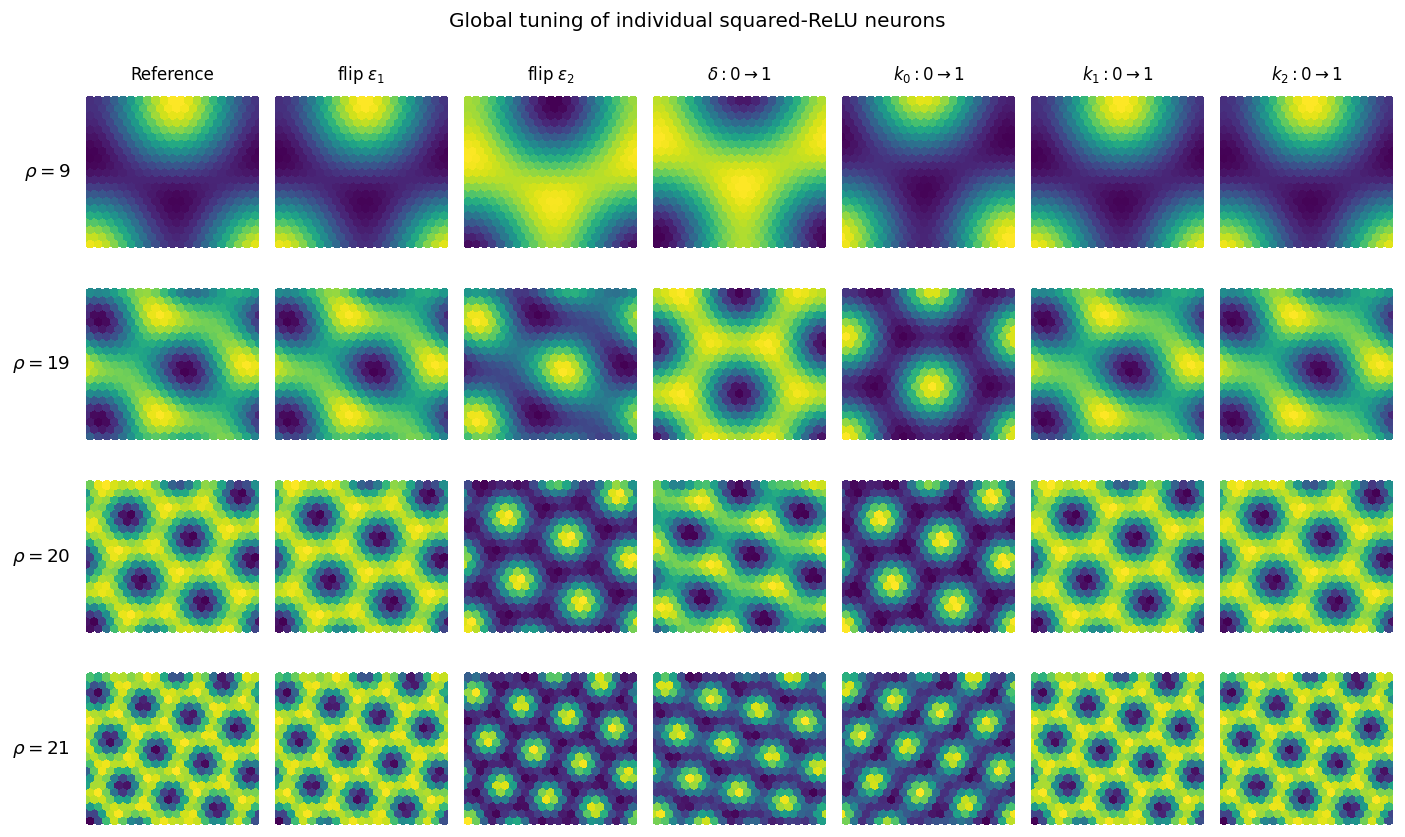

In [21]:
# Figure 12 exports only the complete individual-neuron panel.
# Pairing and M are retained for numerical checks and the Figure 13 analysis.
gallery(single_maps,FIGURE12['rhos'],F12/'full_panel','figure12_single_neurons',
        title='Global tuning of individual squared-ReLU neurons',labels=LABEL_CHANGES,
        save_individual=False)

**Caption draft.** Effects of the neuron indices on individual-neuron global spatial tuning. Rows show four irrep modules; columns change one index of the reference neuron $(\epsilon_1,\epsilon_2,\delta;k_0,k_1,k_2)=(+1,+1,0;0,0,0)$. All maps are computed from squared-ReLU responses and normalized independently for display. Flipping $\epsilon_2$ approximately reverses the spatial modulation, while changes to $\delta$ and $k_0$ alter the pattern. The spatial effects of $k_1$ and $k_2$ are evaluated for these modules and the stated reference encoding. Pairing over $\epsilon_1$ makes the relation to $C_i+\operatorname{Re}\operatorname{Tr}(Q(g)M_i)$ exact; Figure 13 compares both signs with the directly computed sigma-pi interaction for the same four modules.

## Figure 13 — Squared-ReLU channels and direct sigma-pi tuning

This **4-row × 3-column** panel uses the same modules as Figure 12: $\rho=9,19,20,21$. Each row holds $\rho$ and all reference indices fixed. The first two columns show **individual** squared-ReLU neurons with $\epsilon_1=+1$ and $\epsilon_2=+1,-1$, respectively. The third column shows the directly computed, signed sigma-pi activation, averaged over the same global inputs and then over target headings. Change `FIGURE13['rhos']` to select other rows.

### Why are the ReLU maps opposite?

Let $U(a)$ and $V_0(b)$ be the two sign-free scalar inputs, with $b=a^{-1}g$. Write $\langle\cdot\rangle_g$ for a uniform average over every $a\in G$ at a fixed target pose $g$. The individual rates and the direct product are
\[
r_{\epsilon_1,\epsilon_2}(g)
=\big\langle\mathrm{ReLU}\!\left(\epsilon_1[U+\epsilon_2V_0]\right)^2\big\rangle_g,
\qquad P(g)=\langle UV_0\rangle_g.
\]
The identity $\mathrm{ReLU}(z)^2+\mathrm{ReLU}(-z)^2=z^2$ gives, after pairing over $\epsilon_1$,
\[
s_\pm(g)=r_{+1,\pm1}(g)+r_{-1,\pm1}(g)
=\langle(U\pm V_0)^2\rangle_g=C\pm2P(g).
\]
Here $C=\langle U^2+V_0^2\rangle_g$ is independent of $g$: both $a$ and $a^{-1}g$ run through the entire group. Thus the **centered paired curves** are exact opposites. Their raw sum is the positive, spatially constant baseline $2C$, while their difference isolates the interaction:
\[
s_++s_-=2C,\qquad P=\frac{s_+-s_-}{4}.
\]
For the **individual neurons displayed**, inversion is generally only approximate. Since $\mathrm{ReLU}(z)^2=\tfrac12z^2+\tfrac12z|z|$, rectification can leave a small structured residual in their raw sum. `inversion_diagnostics.csv` reports the inversion correlations and the residual amplitude for every module; the raw individual and paired sums are retained in the numerical arrays.

### What changes with sigma-pi?

Sigma-pi computes the signed product $UV_0$ directly. It therefore does not need separate $\epsilon_2=\pm1$ channels to recover that product through a signed combination of squared-ReLU responses. The plotted product is computed independently by explicit global averaging, then checked against $(s_+-s_-)/4$ at **every pose**, before the heading average.

The product has the same spatial modulation as the positive-$\epsilon_2$ paired channel and the opposite modulation to the negative channel. This does **not** mean multiplication forbids inverted maps: negating either input negates the product. It explains why the canonical product needs only one signed map instead of a redundant pair of rectified channels.

### Display scales and exports

The two squared-ReLU maps share a **viridis** color scale within each row, using the common raw minimum and maximum for that pair. Sigma-pi uses **blue–white–red**, symmetric about zero: blue is negative, white is zero, red is positive. Each product map is divided by its maximum absolute value for display; its sign is never flipped or shifted. These display scales compare shape and polarity, not raw amplitudes between modules or activation types. Exact raw limits are saved in `display_scales.csv`.

The complete panel, optional individual maps, and colorbars are saved under `figure13/panela_comparison/`. The raw maps for all four modules, paired curves, sums, full-pose product, and model settings are saved together in `figure13/data/relu_and_sigma_pi_raw.npz`. The unsigned sum is retained as a diagnostic rather than a main figure column.


In [22]:
# Compute each product directly, then compare with the signed ReLU combination.
comparison_maps={}
sigma_pi_poses={}
inversion_rows=[]
sigma_pi_errors={}
for rho in FIGURE13['rhos']:
    circuit=circuits[rho]
    positive=label_results[rho,'reference']
    negative=label_results[rho,'eps2']
    single_plus=spatial_map(positive['single'])
    single_minus=spatial_map(negative['single'])
    paired_plus=spatial_map(positive['result']['paired'])
    paired_minus=spatial_map(negative['result']['paired'])
    # Raw sums are kept as diagnostics, not displayed as a Figure 13 column.
    single_sum=single_plus+single_minus
    paired_sum=paired_plus+paired_minus
    sigma_pi_pose=circuit.sigma_pi_tuning(BASE_LABELS,batch_size=BATCH_SIZE)
    sigma_pi=spatial_map(sigma_pi_pose)
    from_pairs=(positive['result']['paired']-negative['result']['paired'])/4
    sigma_pi_errors[rho]=float(np.max(abs(sigma_pi_pose-from_pairs)))
    assert sigma_pi_errors[rho]<1e-11
    assert np.max(abs(paired_sum-2*positive['theory']['C']))<1e-11
    sigma_pi_poses[rho]=sigma_pi_pose
    comparison_maps[rho]=dict(eps2_plus=single_plus,eps2_minus=single_minus,
        sigma_pi=sigma_pi,paired_plus=paired_plus,paired_minus=paired_minus,
        single_sum=single_sum,paired_sum=paired_sum)
    for kind,a,b,total in (('single',single_plus,single_minus,single_sum),
                           ('paired',paired_plus,paired_minus,paired_sum)):
        inversion_rows.append(dict(rho=rho,kind=kind,
            eps2_centered_correlation=map_correlation(a,b),
            positive_sigma_pi_correlation=map_correlation(a,sigma_pi),
            negative_sigma_pi_correlation=map_correlation(b,sigma_pi),
            positive_mean=float(a.mean()),negative_mean=float(b.mean()),sum_mean=float(total.mean()),
            positive_peak_to_peak=float(np.ptp(a)),sum_peak_to_peak=float(np.ptp(total)),
            sum_modulation_relative_to_positive=float(np.ptp(total)/max(np.ptp(a),1e-30)),
            direct_sigma_pi_error=sigma_pi_errors[rho]))
    print(f'rho={rho}: direct sigma-pi error {sigma_pi_errors[rho]:.3g}; '
          f'corr(single +, sigma-pi)={map_correlation(single_plus,sigma_pi):.9f}; '
          f'corr(single -, sigma-pi)={map_correlation(single_minus,sigma_pi):.9f}')
write_csv(F13/'inversion_diagnostics.csv',inversion_rows)
save_arrays(F13,'relu_and_sigma_pi_raw',rhos=np.array(FIGURE13['rhos']),
            **{name:np.array([comparison_maps[rho][name] for rho in FIGURE13['rhos']])
               for name in ('eps2_plus','eps2_minus','sigma_pi','paired_plus','paired_minus',
                            'single_sum','paired_sum')},
            sigma_pi_pose=np.array([sigma_pi_poses[rho] for rho in FIGURE13['rhos']]),
            labels_json=np.array(json.dumps(asdict(BASE_LABELS))),
            settings_json=np.array(json.dumps([circuits[rho].settings for rho in FIGURE13['rhos']])))


rho=9: direct sigma-pi error 6.18e-18; corr(single +, sigma-pi)=0.999998846; corr(single -, sigma-pi)=-0.999998842
rho=19: direct sigma-pi error 5.64e-18; corr(single +, sigma-pi)=0.999997602; corr(single -, sigma-pi)=-0.999997606
rho=20: direct sigma-pi error 2.87e-18; corr(single +, sigma-pi)=0.999999485; corr(single -, sigma-pi)=-0.999999362
rho=21: direct sigma-pi error 1.73e-18; corr(single +, sigma-pi)=0.999999731; corr(single -, sigma-pi)=-0.999999714


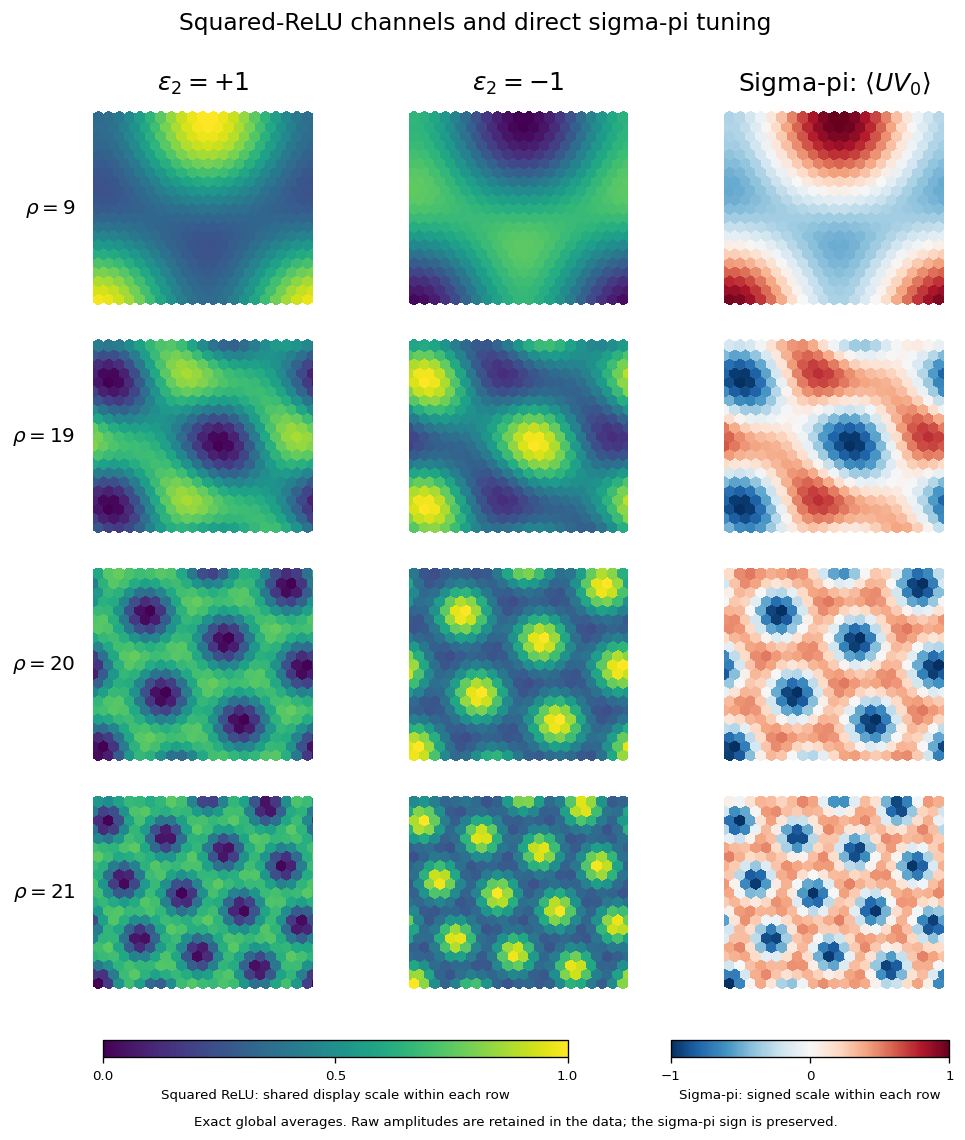

In [23]:
# Four modules by three columns; product polarity is never changed for display.
folder=F13/'panela_comparison'
rhos=FIGURE13['rhos']
nrows=len(rhos)
fig,axes=plt.subplots(nrows,3,figsize=(8.6,2.18*nrows+.9),squeeze=False)
fig.subplots_adjust(left=.10,right=.985,bottom=.13,top=.89,wspace=.12,hspace=.18)
scale_rows=[]
for row,rho in enumerate(rhos):
    maps=comparison_maps[rho]
    a,b,P=(maps[key] for key in ('eps2_plus','eps2_minus','sigma_pi'))
    lo,hi=min(a.min(),b.min()),max(a.max(),b.max())
    width=max(float(hi-lo),1e-15)
    product_scale=max(float(np.max(abs(P))),1e-15)
    # The ReLU pair shares one color scale within this module. The product
    # uses symmetric limits about zero, preserving its sign and relative lobes.
    specs=(('eps2_plus',(a-lo)/width,'viridis',0,1),
           ('eps2_minus',(b-lo)/width,'viridis',0,1),
           ('sigma_pi',P/product_scale,FIGURE13['sigma_pi_cmap'],-1,1))
    for col,(slug,values,cmap,vmin,vmax) in enumerate(specs):
        plot_lattice(values,axes[row,col],cmap=cmap,vmin=vmin,vmax=vmax)
        if FIGURE13['save_individual_panels']:
            scalar_panel(values,folder,f'rho{rho:02d}_{slug}',cmap=cmap,vmin=vmin,vmax=vmax)
    axes[row,0].text(-.08,.5,rf'$\rho={rho}$',transform=axes[row,0].transAxes,
                     ha='right',va='center',fontsize=12)
    scale_rows.append(dict(rho=rho,relu_min=float(lo),relu_max=float(hi),
                           sigma_pi_abs_max=product_scale))
for ax,title in zip(axes[0],(r'$\epsilon_2=+1$',r'$\epsilon_2=-1$',r'Sigma-pi: $\langle UV_0\rangle$')):
    ax.set_title(title,fontsize=15,pad=13)
fig.suptitle('Squared-ReLU channels and direct sigma-pi tuning',fontsize=14,y=.977)
# Two compact legends describe the per-module scaling without adding a bar to
# each map. Exact raw limits are also saved in display_scales.csv.
relu_bar=fig.add_axes([.14,.071,.45,.015])
cb=fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(0,1),cmap='viridis'),cax=relu_bar,
                orientation='horizontal',ticks=[0,.5,1])
cb.set_label('Squared ReLU: shared display scale within each row',fontsize=8)
cb.ax.tick_params(labelsize=8)
product_bar=fig.add_axes([.69,.071,.27,.015])
cb=fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(-1,1),cmap=FIGURE13['sigma_pi_cmap']),
                cax=product_bar,orientation='horizontal',ticks=[-1,0,1])
cb.set_label('Sigma-pi: signed scale within each row',fontsize=8)
cb.ax.tick_params(labelsize=8)
fig.text(.54,.012,'Exact global averages. Raw amplitudes are retained in the data; the sigma-pi sign is preserved.',
         ha='center',fontsize=8)
export_figure(fig,folder,'figure13_comparison',show=True)
colorbar_panel(folder,'relu_display_colorbar','viridis',0,1,'Display-normalized squared-ReLU activity')
colorbar_panel(folder,'sigma_pi_display_colorbar',FIGURE13['sigma_pi_cmap'],-1,1,'Signed product / maximum absolute product')
write_csv(F13/'display_scales.csv',scale_rows)


**Caption draft.** Individual squared-ReLU and signed sigma-pi spatial tuning for the same four irrep modules as Figure 12. Rows show $\rho=9,19,20,21$; columns show $\epsilon_2=+1$, $\epsilon_2=-1$, and the direct product $\langle UV_0\rangle$. All other reference indices are held fixed. Each map averages uniformly over the global inputs and target headings. The squared-ReLU pair shares a viridis scale within each row. Sigma-pi uses a symmetric blue–white–red scale centered at zero and is normalized by its maximum absolute value, preserving polarity. Individual ReLU maps are nearly opposite; exact inversion holds after pairing over $\epsilon_1$, which yields $s_\pm=C\pm2\langle UV_0\rangle$. The direct product agrees with $(s_+-s_-)/4$ to floating-point precision. Raw amplitudes and the exact display limits are saved separately.


## Export manifest and measured summary

The main assets are listed below. Re-running a figure overwrites its named exports. Cached tuning is keyed by the numerical settings, labels, and implementation; changing labels or the reference does not reuse incompatible cached data. To force a clean computation, set `USE_CACHE=False` and run the setup again.

In [24]:
manifest={
    'source_notebook':'grid-cell-phenomenology-old.ipynb',
    'n':N,'q':Q,'averaging':'global_uniform','action_side':'right',
    'figure11':FIGURE11,'figure12':FIGURE12,'figure13':FIGURE13,
    'reference_center':REFERENCE_CENTER,'reference_sigma':REFERENCE_SIGMA,
    'heading_weights':HEADING_WEIGHTS,'baseline_labels':asdict(BASE_LABELS),
    'files':sorted(set(str(p.relative_to(OUTPUT_ROOT)) for p in exported_paths)),
    'inversion_diagnostics':inversion_rows,
    'max_M_formula_error':max(r['M_formula_max_error'] for r in effect_rows),
    'max_direct_sigma_pi_error':max(sigma_pi_errors.values()),
}
(OUTPUT_ROOT/'manifest.json').write_text(json.dumps(manifest,indent=2))
for folder,stem in [(F11,'figure11_overview'),
                    (F12/'full_panel','figure12_single_neurons'),
                    (F13/'panela_comparison','figure13_comparison')]:
    print(folder/f'{stem}.{EXPORT_FORMATS[0]}')
print(f'Exported {len(manifest["files"])} figure/data files; manifest: {OUTPUT_ROOT/"manifest.json"}')
print('\nSelected label effects (maximum change of display-normalized spatial maps):')
for rho in FIGURE12['rhos']:
    for kind in ('single','paired'):
        rows=[r for r in effect_rows if r['rho']==rho and r['kind']==kind]
        print(rho,kind,', '.join(f"{r['label']}={r['max_display_shape_change']:.3g}" for r in rows[1:]))

appendix_figures/figure11/figure11_overview.svg
appendix_figures/figure12/full_panel/figure12_single_neurons.svg
appendix_figures/figure13/panela_comparison/figure13_comparison.svg
Exported 111 figure/data files; manifest: appendix_figures/manifest.json

Selected label effects (maximum change of display-normalized spatial maps):
9 single eps1=0.00338, eps2=1, delta=0.974, k0=0.289, k1=3.77e-15, k2=6.38e-15
9 paired eps1=0, eps2=1, delta=0.973, k0=0.288, k1=7.44e-15, k2=7.99e-15
19 single eps1=0.00338, eps2=1, delta=0.721, k0=0.839, k1=8.27e-15, k2=6.55e-15
19 paired eps1=0, eps2=1, delta=0.721, k0=0.839, k1=6.77e-15, k2=9.99e-15
20 single eps1=0.00239, eps2=1, delta=0.72, k0=0.968, k1=3.22e-15, k2=4.33e-15
20 paired eps1=0, eps2=1, delta=0.721, k0=0.968, k1=5.77e-15, k2=5.44e-15
21 single eps1=0.00133, eps2=1, delta=0.912, k0=0.902, k1=2.28e-15, k2=1.94e-15
21 paired eps1=0, eps2=1, delta=0.912, k0=0.902, k1=2.55e-15, k2=2.33e-15
